<a href="https://colab.research.google.com/github/kurniarahmi/Sales-Revenue-Analysis/blob/main/python/Sales_%26_Revenue_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install google-cloud-bigquery pandas matplotlib seaborn

In [2]:
pip install pyarrow

In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
from google.cloud import bigquery
import pandas as pd
client = bigquery.Client(project='fair-hallway-256512')

## Dataset yang digunakan

In [5]:
query = """
SELECT
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.sale_price,
  oi.created_at,
  u.country,
  p.name
FROM
  bigquery-public-data.thelook_ecommerce.order_items oi
JOIN
  bigquery-public-data.thelook_ecommerce.users u
ON
  oi.user_id = u.id
JOIN
  bigquery-public-data.thelook_ecommerce.products p
ON
  oi.product_id = p.id
"""

df = client.query(query).to_dataframe()

In [6]:
df

,order_id,user_id,product_id,sale_price,created_at,country,name
0,11189,9028,29033,3.95,2024-07-07 19:33:40+00:00,Poland,HDE Pattern Suspenders
1,95861,76643,14225,5.99,2024-07-20 07:35:24+00:00,Poland,New Classy Womens Skinny Leather Belt with Shi...
2,111531,89097,25322,5.99,2023-02-14 10:43:06+00:00,Poland,RHINO SOCKS SS series Bikapelli crimson/navy a...
3,101540,81193,9498,6.99,2026-03-17 18:09:17+00:00,Poland,Soxnet Women's Neon Socks - Solid Colors Low C...
4,59561,47836,14116,6.99,2026-02-03 22:04:52+00:00,Poland,Premium Flower Print Scarf (2 Colors Available...
...,...,...,...,...,...,...,...
181582,117774,94092,8429,903.00,2023-10-23 20:17:40+00:00,United States,The North Face Women's S-XL Oso Jacket
181583,70929,56826,24110,990.00,2025-10-22 04:00:24+00:00,United States,Woolrich Arctic Parka DF
181584,100496,80357,24110,990.00,2026-01-25 12:54:32+00:00,United States,Woolrich Arctic Parka DF
181585,51182,41070,24447,999.00,2023-06-06 02:25:00+00:00,United States,Darla


## Cleaning Data

In [7]:
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.dropna()

In [8]:
df['month'] = df['created_at'].dt.to_period('M')

/tmp/ipykernel_12187/4241509362.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['created_at'].dt.to_period('M')
/tmp/ipykernel_12187/4241509362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['created_at'].dt.to_period('M')


#Exploratory Data Analysis (EDA)

## Revenue Trend

<Axes: xlabel='month'>

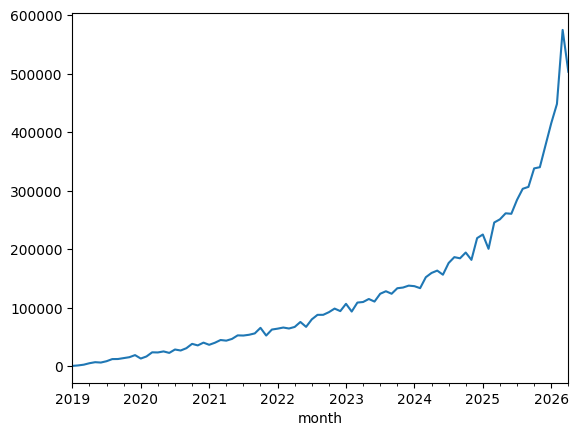

In [9]:
monthly_revenue = df.groupby('month')['sale_price'].sum()
monthly_revenue.plot()

* Revenue menunjukkan tren naik konsisten tanpa penurunan signifikan
* Di periode akhir terlihat akselerasi growth (makin cepat naik)
* Volatilitas rendah → bisnis relatif stabil
* Belum ada tanda plateau → masih ada potensi growth lebih lanjut

##Top Product Contribution

In [10]:
top_products = df.groupby('name')['sale_price'].sum().sort_values(ascending=False).head(10)

In [11]:
top_products

,sale_price
name,
NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outstanding Support and Comfort*,13545.0
The North Face Apex Bionic Soft Shell Jacket - Men's,12642.0
Diesel Men's Jimeneo Jacket,11866.0
Woolrich Arctic Parka DF,10890.0
Darla,9990.0
Faconnable Men's Reversible Trench Coat,9200.0
Canada Goose Women's Solaris,9035.0
The North Face Denali Down Womens Jacket 2013,9030.0
Canada Goose Women's Mystique,8250.0


* Revenue didominasi oleh produk premium (outerwear & brand besar) → kontribusi tinggi meskipun jumlah produk sedikit
* Top products menunjukkan pola high-value, low-volume (harga tinggi jadi driver utama revenue)
* Ada sedikit variasi (jeans, shorts), tapi tetap kalah kontribusi dibanding jacket premium

In [12]:
worst_products = df.groupby('name')['sale_price'].sum().sort_values(ascending=True).head(10)
worst_products

,sale_price
name,
Indestructable Aluminum Aluma Wallet - RED,0.10
Set of 2 - Replacement Insert For Checkbook Wallets Card Or Picture Insert,1.47
Individual Bra Extenders,1.75
Pink Ribbon Breast Cancer Awareness Relay for Life Knee Socks Great for Fundraising Walk Survivor (Style 05),2.95
Loravicci Womens Pink Short W/Draw String,4.99
Black Belt for Buckle,5.33
Designer Bow Ties for Men & Boys by Tok Tok Designs (Y166),5.90
Alivila.Y Fashion Sexy Lace Long Sleeve Lingerie Sleepwear Sleep Dress Set With G-String 481,5.98
Angelina Arm Warmer / Sleeves Extension,5.99


* Worst products punya revenue sangat kecil → indikasi low price, low impact, bahkan berpotensi tidak profitable
* Terdapat long-tail distribution → sebagian kecil produk menyumbang mayoritas revenue

##Customer Value Analysis

In [13]:
customer_value = df.groupby('user_id')['sale_price'].sum()
customer_value.describe()

,sale_price
count,80063.000000
mean,135.075582
std,138.738602
min,1.500000
25%,41.950001
50%,89.330002
75%,181.444998
max,1906.870010


* Distribusi nilai transaksi menunjukkan right-skewed (condong ke kanan) → sebagian besar transaksi bernilai rendah, tapi ada sedikit transaksi dengan nilai sangat tinggi (max 1936)
* Median (89) jauh lebih rendah dari mean (134) → menandakan outlier high-value cukup signifikan dan mendorong rata-rata naik
50% transaksi berada di range 41 – 180 → ini adalah core spending customer (mid-range)
* Adanya nilai minimum sangat kecil (0.02) → indikasi anomali data atau diskon ekstrem

👉 mayoritas customer belanja di level rendah–menengah, tapi revenue sangat dipengaruhi oleh transaksi high-value (premium segment)

#Deep Analysis

##RFM Analysis

In [14]:
import datetime as dt

snapshot_date = df['created_at'].max()

rfm = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'sale_price': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']


In [15]:
rfm

,recency,frequency,monetary
user_id,,,
1,22,2,133.919998
2,925,1,49.500000
3,981,2,105.450001
4,867,2,98.950001
5,5,1,53.959999
...,...,...,...
99996,2075,1,29.990000
99997,1492,1,124.989998
99998,732,1,22.990000


## Distribusi RFM (Recency, Frequency, Monetary)

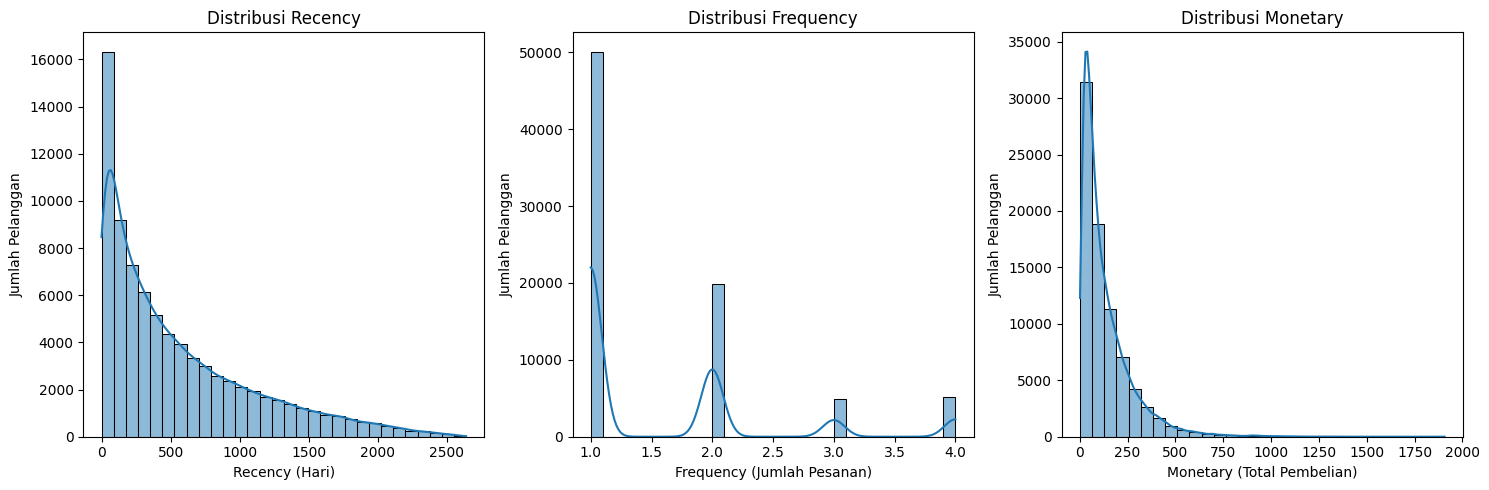

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# Recency distribution
plt.subplot(1, 3, 1)
sns.histplot(rfm['recency'], bins=30, kde=True)
plt.title('Distribusi Recency')
plt.xlabel('Recency (Hari)')
plt.ylabel('Jumlah Pelanggan')

# Frequency distribution
plt.subplot(1, 3, 2)
sns.histplot(rfm['frequency'], bins=30, kde=True)
plt.title('Distribusi Frequency')
plt.xlabel('Frequency (Jumlah Pesanan)')
plt.ylabel('Jumlah Pelanggan')

# Monetary distribution
plt.subplot(1, 3, 3)
sns.histplot(rfm['monetary'], bins=30, kde=True)
plt.title('Distribusi Monetary')
plt.xlabel('Monetary (Total Pembelian)')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.show()

* Recency: Distribusi condong ke kanan → banyak customer sudah lama tidak bertransaksi → indikasi churn cukup tinggi / engagement menurun
* Frequency: Mayoritas customer hanya melakukan 1–2 transaksi → menunjukkan repeat rate masih rendah
* Monetary: Distribusi sangat skewed → sebagian besar customer spend kecil, hanya sedikit yang high-value

Singkatnya:
Customer base didominasi oleh low engagement (jarang beli & sudah lama tidak aktif). Sementara, Revenue kemungkinan besar ditopang oleh segelintir customer yang sering dan belanja besar dan ada peluang besar di retention & increasing purchase frequency

## Cohort Analysis

### Retention per Cohort (Yearly)

In [17]:
df['order_year'] = df['created_at'].dt.to_period('Y')
df['cohort'] = df.groupby('user_id')['order_year'].transform('min')

cohort_data = df.groupby(['cohort', 'order_year'])['user_id'].nunique().reset_index()

/tmp/ipykernel_12187/769042606.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['order_year'] = df['created_at'].dt.to_period('Y')
/tmp/ipykernel_12187/769042606.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_year'] = df['created_at'].dt.to_period('Y')
/tmp/ipykernel_12187/769042606.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cohort'] = df.groupby('user_id')['order_year'].transform('min')


In [19]:
cohort_data

,cohort,order_year,user_id,period_number
0,2019,2019,1136,0
1,2019,2020,155,1
2,2019,2021,162,2
3,2019,2022,137,3
4,2019,2023,158,4
5,2019,2024,156,5
6,2019,2025,171,6
7,2019,2026,36,7
8,2020,2020,3503,0
9,2020,2021,520,1


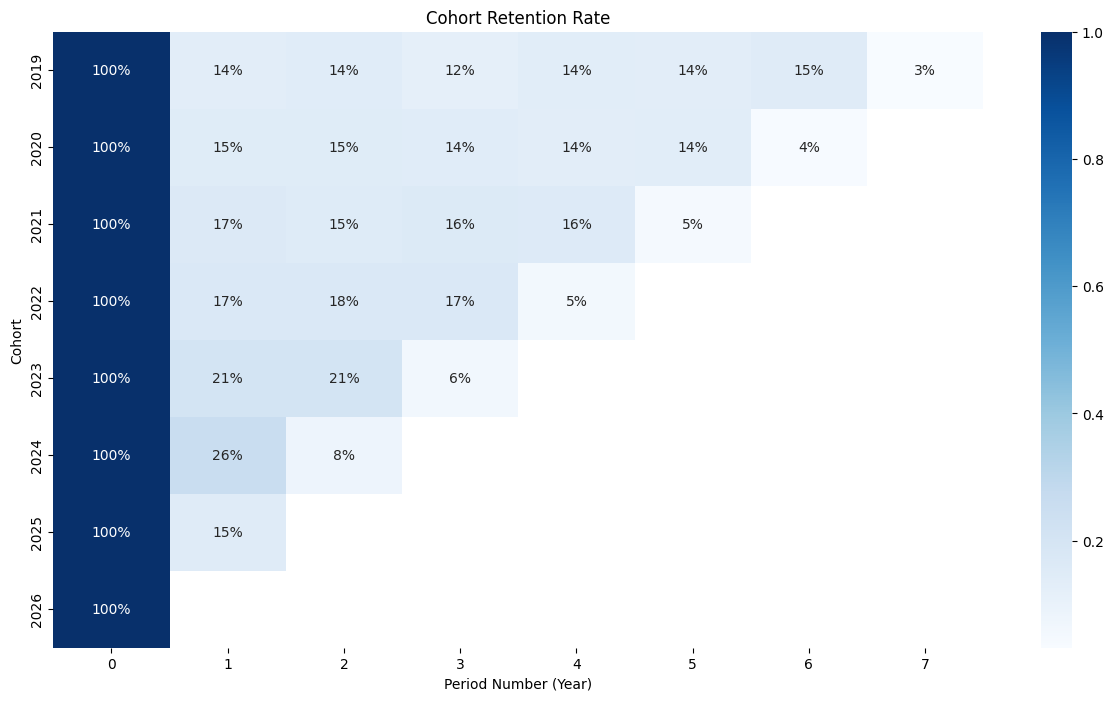

In [18]:
cohort_data['period_number'] = (cohort_data.order_year - cohort_data.cohort).apply(lambda x: x.n)

cohort_pivot = cohort_data.pivot_table(index='cohort', columns='period_number', values='user_id')

cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

plt.figure(figsize=(15, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='Blues')
plt.title('Cohort Retention Rate')
plt.xlabel('Period Number (Year)')
plt.ylabel('Cohort')
plt.show()

* Retention rate turun drastis setelah periode pertama → dari 100% ke ~15–26% di tahun berikutnya → indikasi drop-off tinggi setelah pembelian awal
* Setelah tahun ke-2/ke-3, retention makin menurun hingga <10% → sangat sedikit customer yang bertahan jangka panjang
* Cohort yang lebih baru (2023–2024) sempat menunjukkan retention awal lebih tinggi (~21–26%), tapi tetap turun cepat di periode berikutnya
* Pola ini konsisten di hampir semua cohort → menunjukkan masalah struktural di retention, bukan kasus tertentu

### Retention per Cohort (Monthly per Year)


--- Cohort Analysis for Year: 2019 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


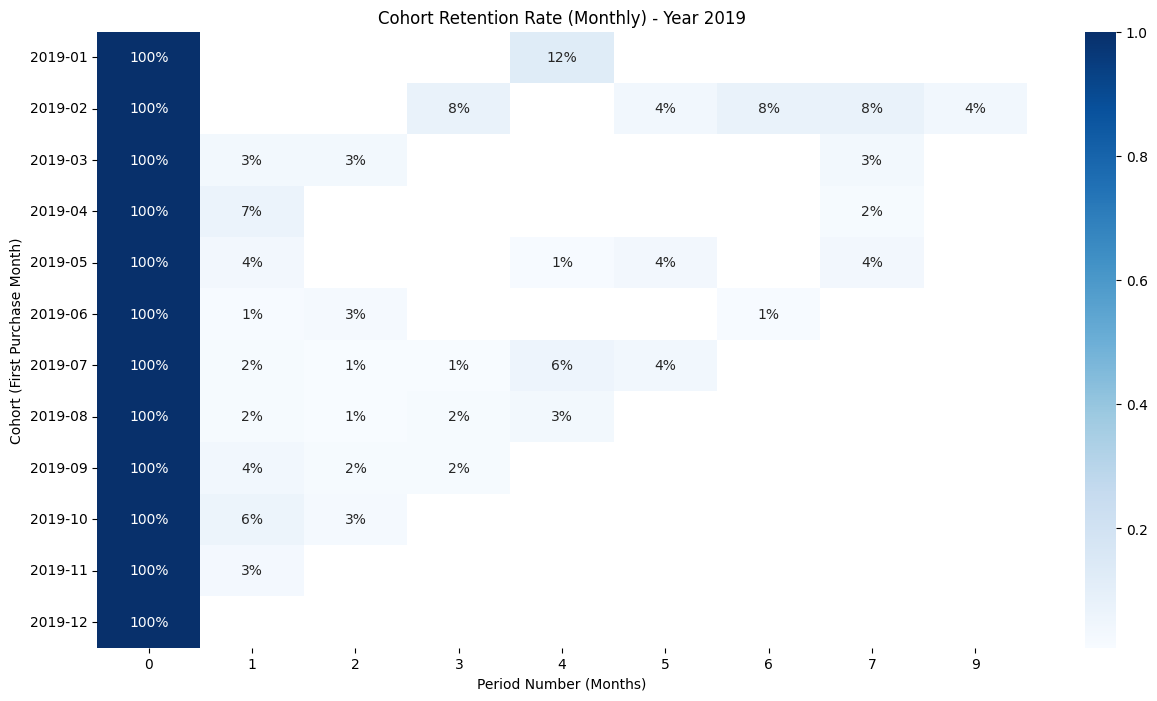


--- Cohort Analysis for Year: 2020 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


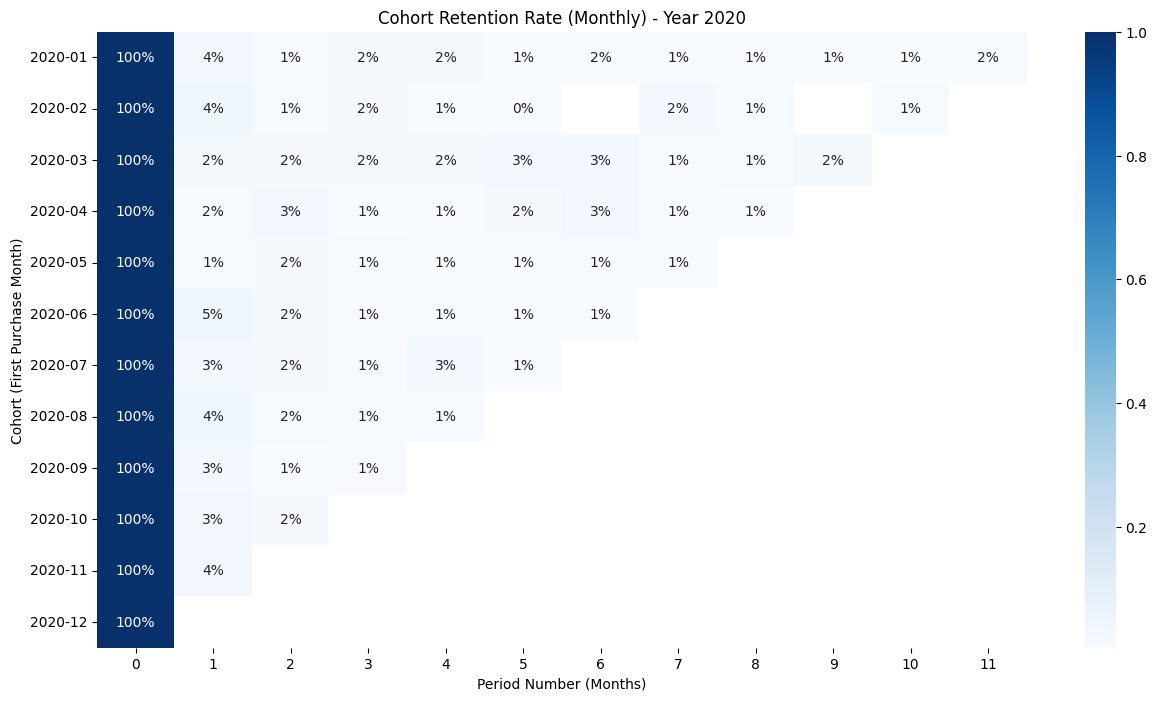


--- Cohort Analysis for Year: 2021 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


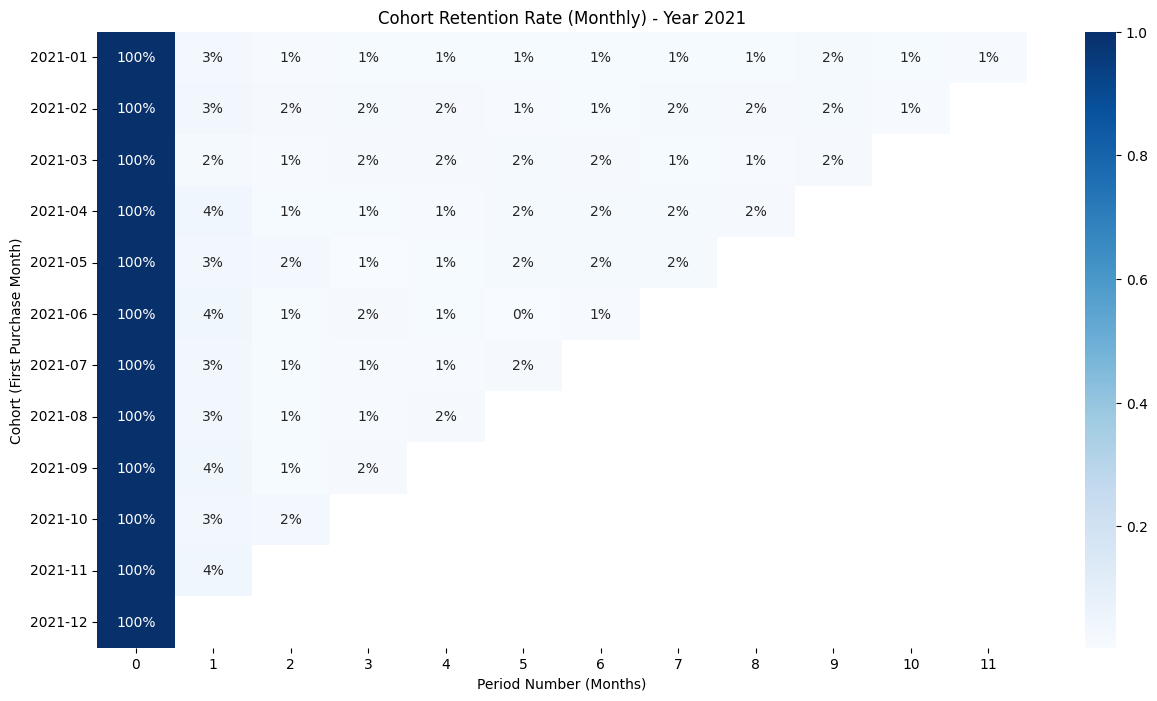


--- Cohort Analysis for Year: 2022 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


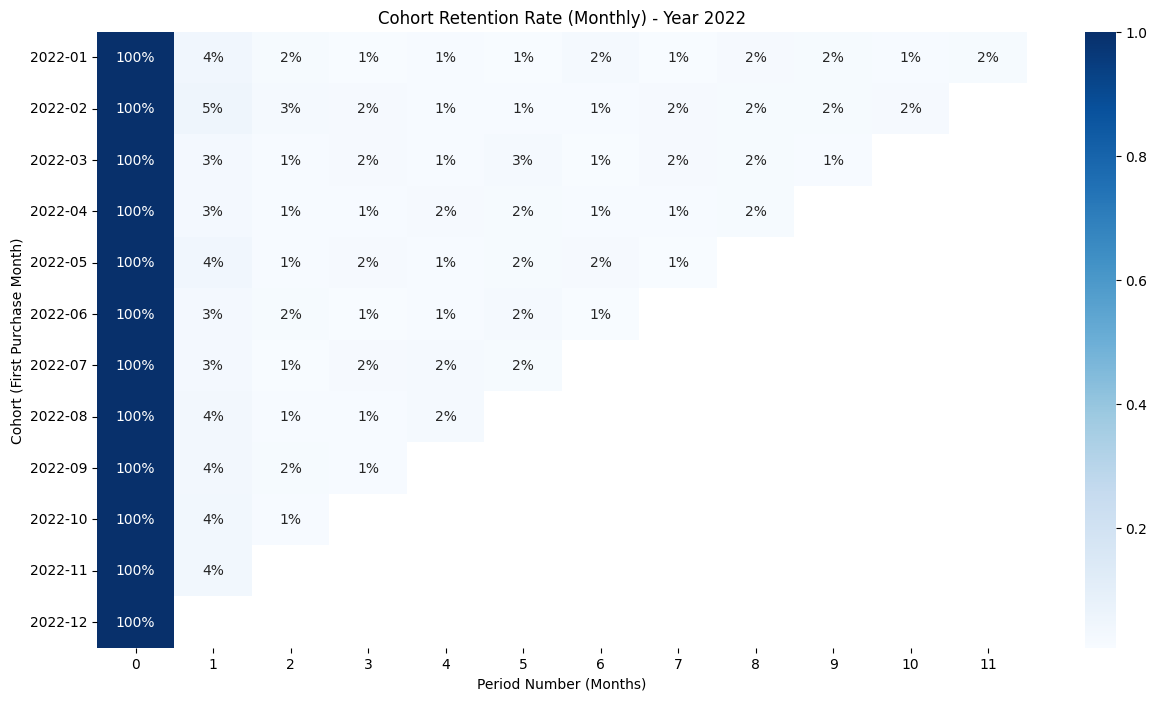


--- Cohort Analysis for Year: 2023 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


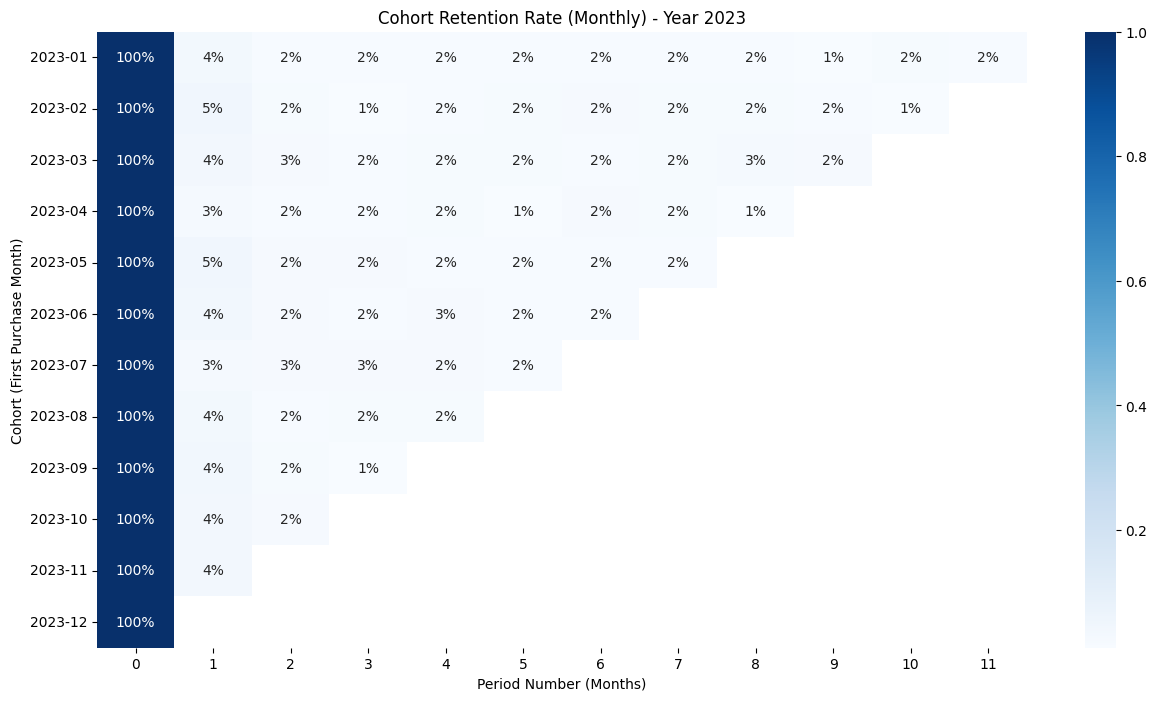


--- Cohort Analysis for Year: 2024 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


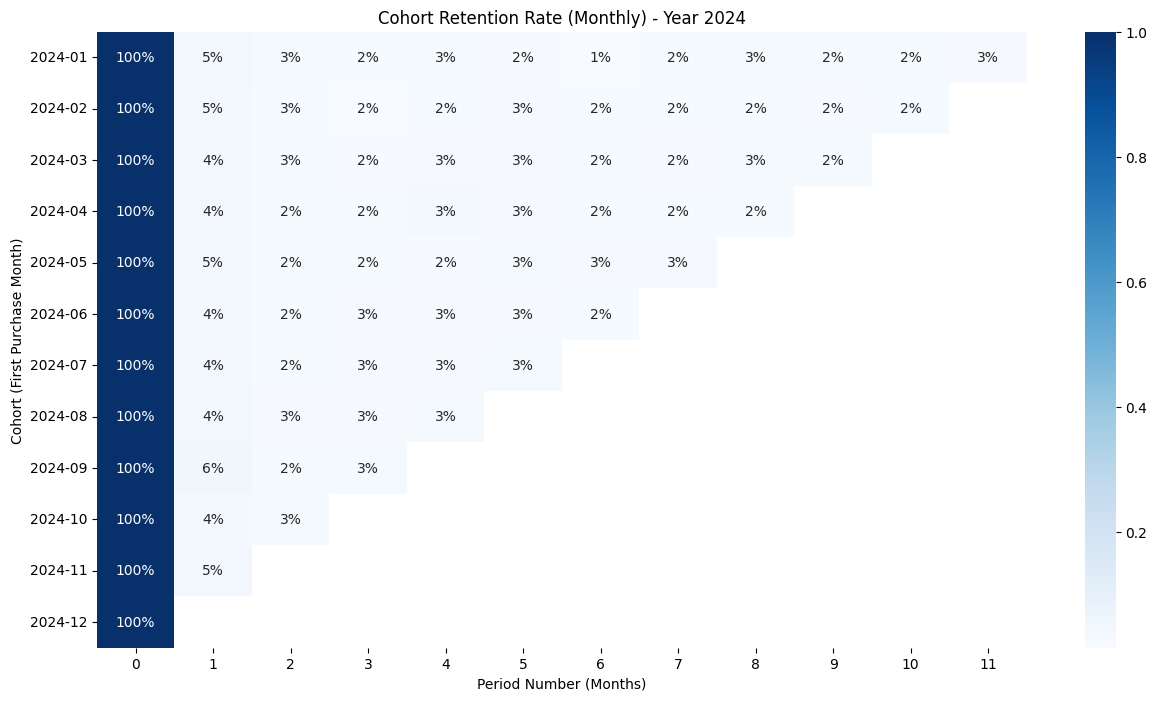


--- Cohort Analysis for Year: 2025 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


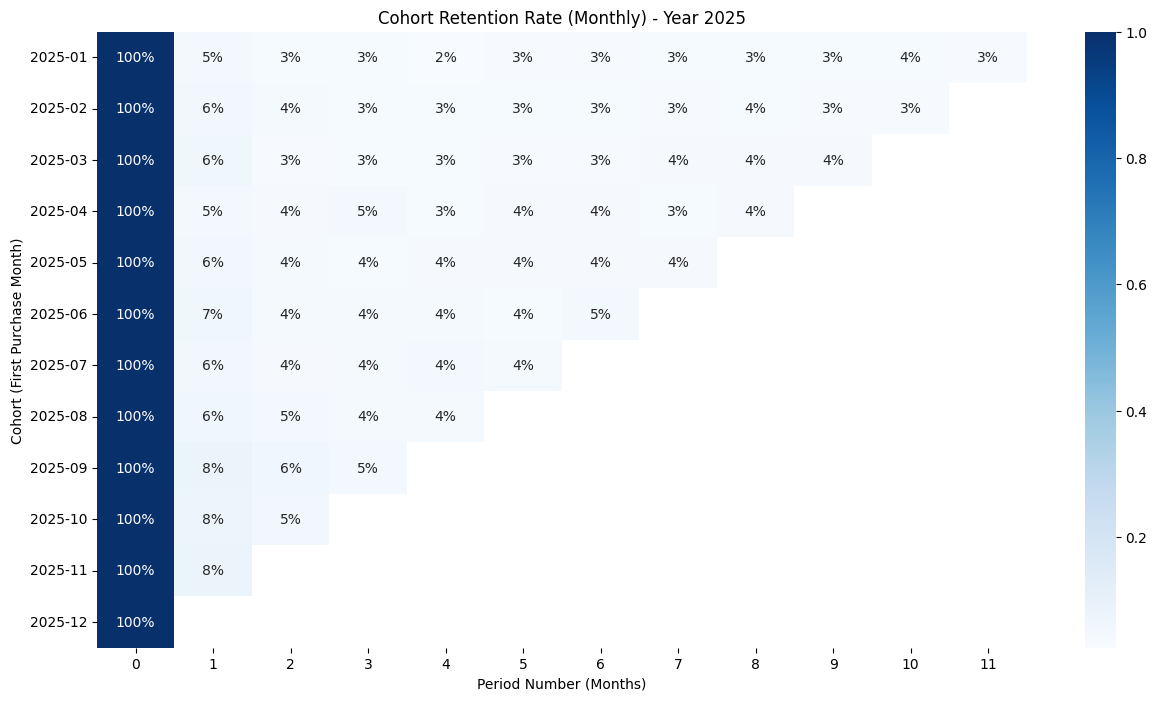


--- Cohort Analysis for Year: 2026 ---


/tmp/ipykernel_12187/3640800233.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


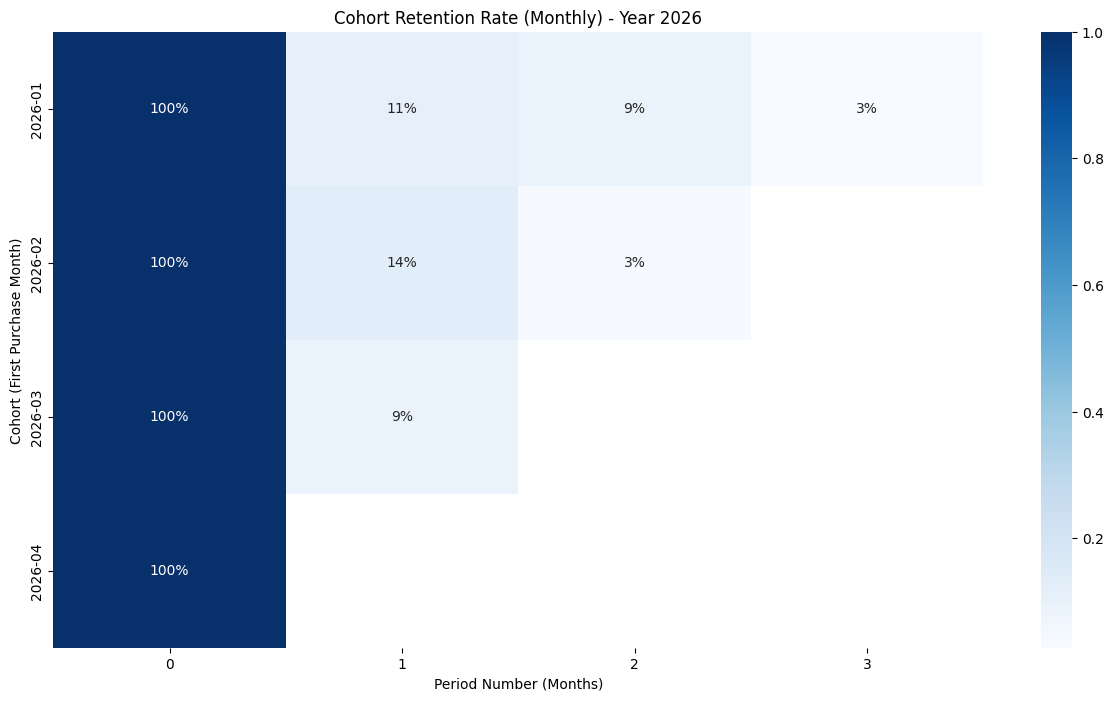

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique years from the DataFrame
all_years = sorted(df['created_at'].dt.year.unique())

for year in all_years:
    print(f"\n--- Cohort Analysis for Year: {year} ---")

    # Filter data for the current year
    df_year = df[df['created_at'].dt.year == year].copy()

    if df_year.empty:
        print(f"No data for year {year}, skipping.")
        continue

    # Define order_month and cohort for the current year
    df_year['order_month'] = df_year['created_at'].dt.to_period('M')
    df_year['cohort'] = df_year.groupby('user_id')['order_month'].transform('min')

    # Aggregate cohort data
    cohort_data_yearly = df_year.groupby(['cohort', 'order_month'])['user_id'].nunique().reset_index()

    # Calculate period number
    cohort_data_yearly['period_number'] = (cohort_data_yearly.order_month - cohort_data_yearly.cohort).apply(lambda x: x.n)

    # Create pivot table
    cohort_pivot_yearly = cohort_data_yearly.pivot_table(index='cohort', columns='period_number', values='user_id')

    # Calculate retention matrix
    cohort_sizes_yearly = cohort_pivot_yearly.iloc[:,0]
    retention_matrix_yearly = cohort_pivot_yearly.divide(cohort_sizes_yearly, axis=0)

    # Plot heatmap
    plt.figure(figsize=(15, 8))
    sns.heatmap(retention_matrix_yearly, annot=True, fmt='.0%', cmap='Blues')
    plt.title(f'Cohort Retention Rate (Monthly) - Year {year}')
    plt.xlabel('Period Number (Months)')
    plt.ylabel('Cohort (First Purchase Month)')
    plt.show()


### Churn Rate per Cohort (Yearly)

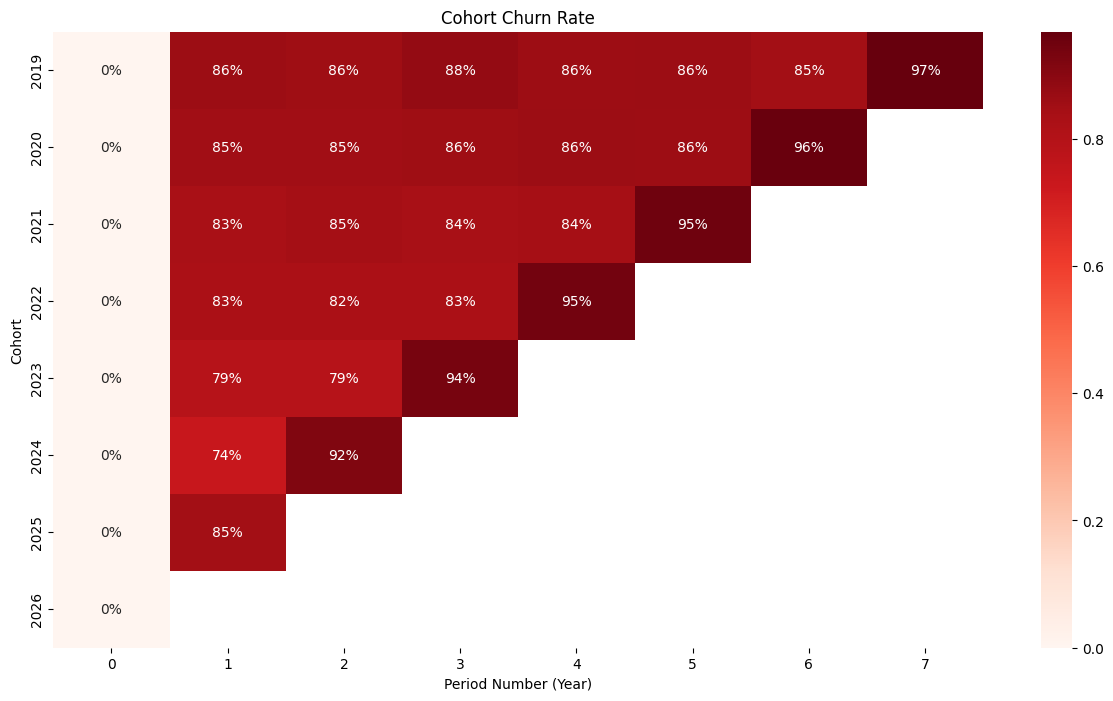

In [21]:
# Calculate churn matrix (1 - retention_matrix)
churn_matrix = 1 - retention_matrix

plt.figure(figsize=(15, 8))
sns.heatmap(churn_matrix, annot=True, fmt='.0%', cmap='Reds')
plt.title('Cohort Churn Rate')
plt.xlabel('Period Number (Year)')
plt.ylabel('Cohort')
plt.show()

### Churn Rate per Cohort (Monthly per Year)


--- Cohort Churn Analysis for Year: 2019 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


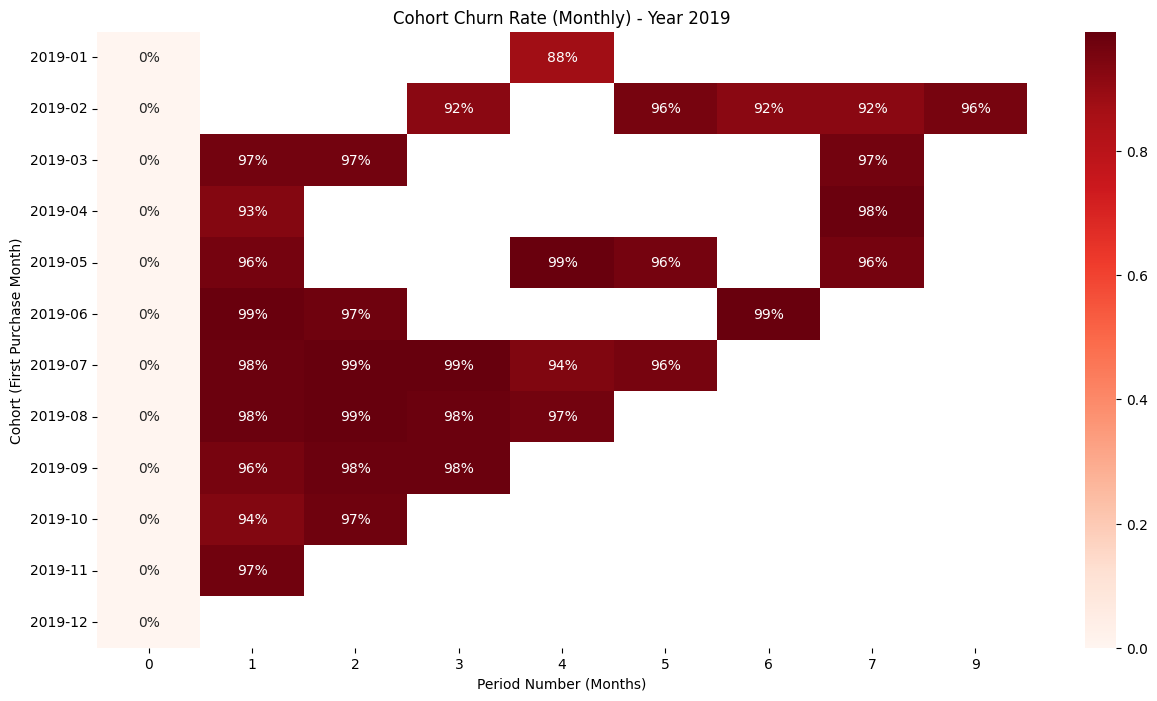


--- Cohort Churn Analysis for Year: 2020 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


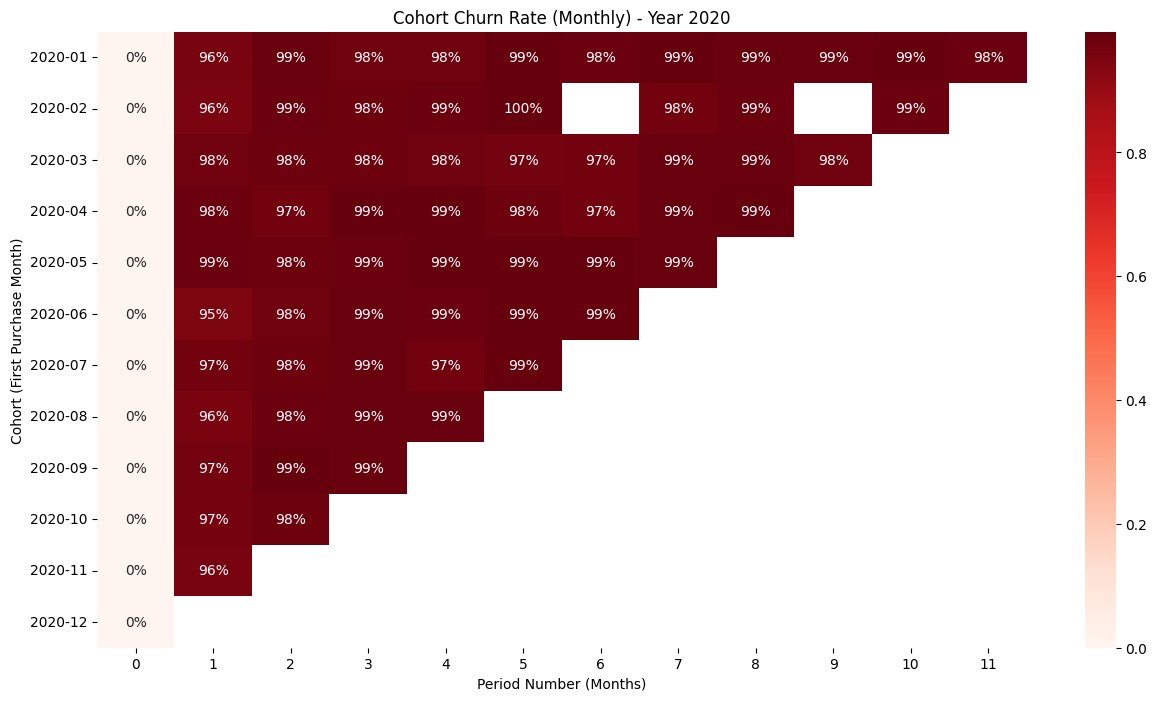


--- Cohort Churn Analysis for Year: 2021 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


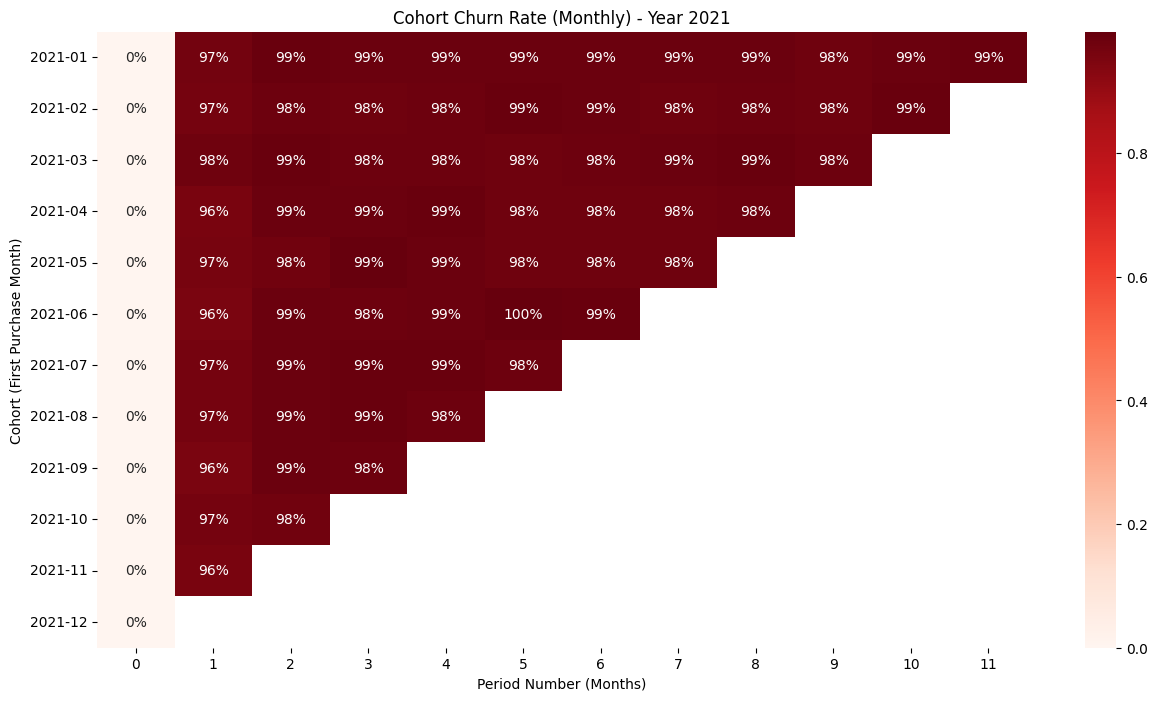


--- Cohort Churn Analysis for Year: 2022 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


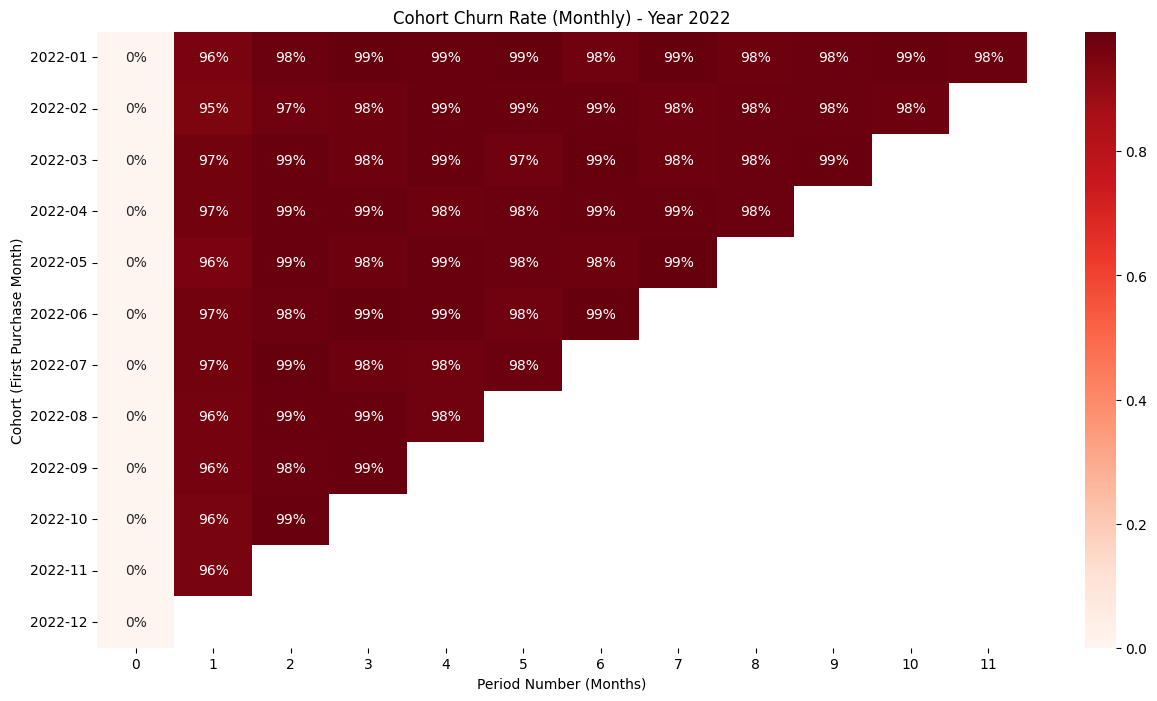


--- Cohort Churn Analysis for Year: 2023 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


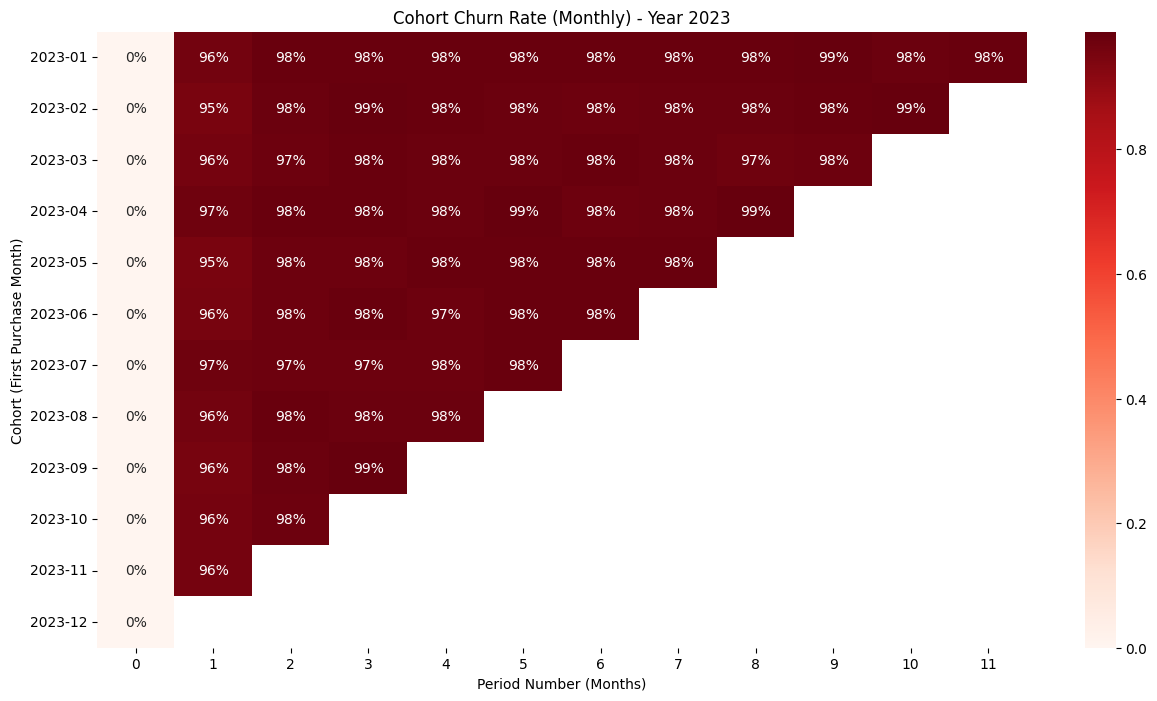


--- Cohort Churn Analysis for Year: 2024 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


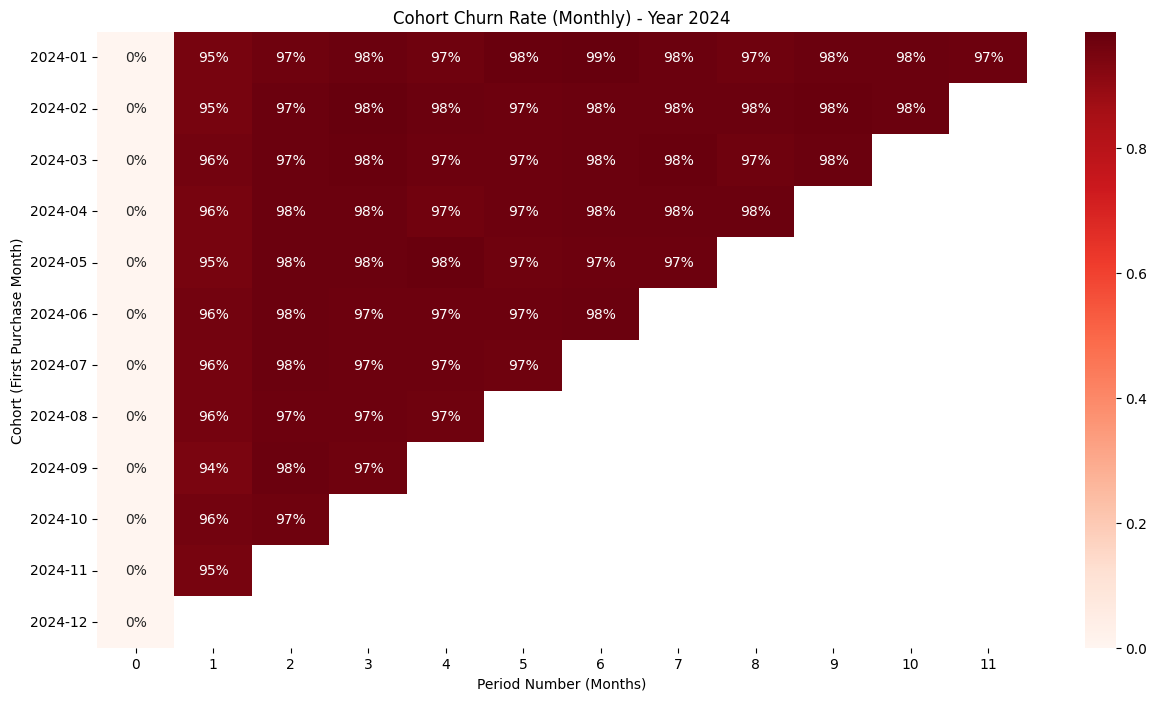


--- Cohort Churn Analysis for Year: 2025 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


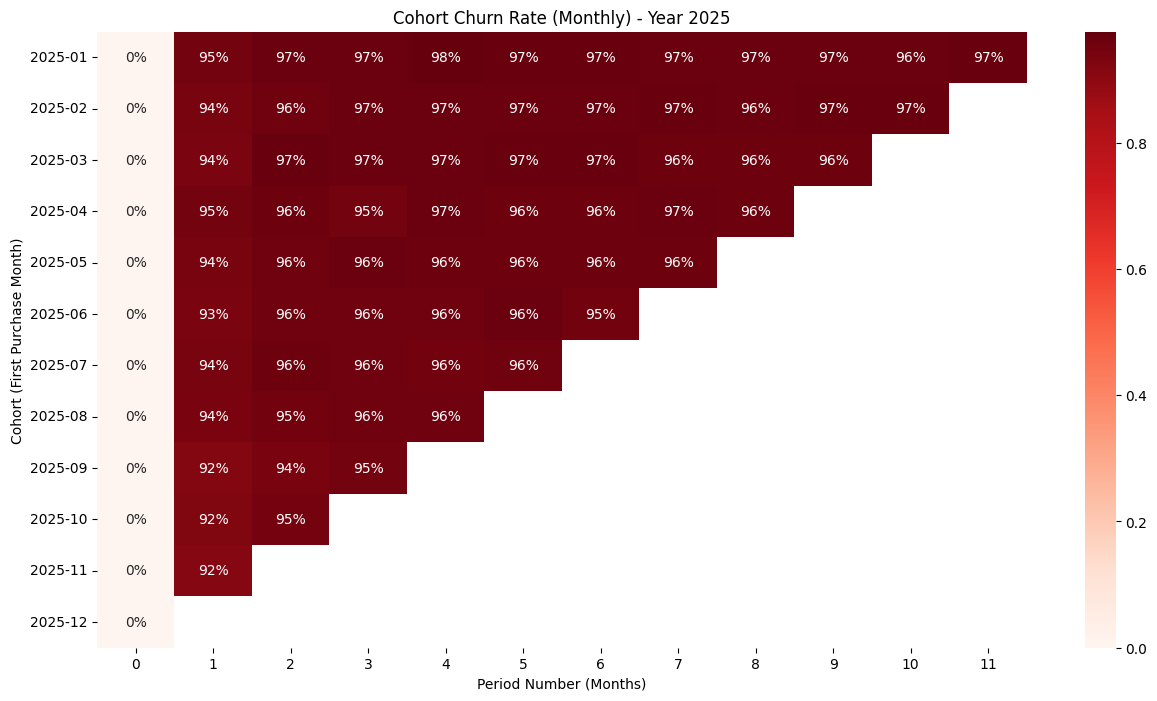


--- Cohort Churn Analysis for Year: 2026 ---


/tmp/ipykernel_12187/3331634551.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_year['order_month'] = df_year['created_at'].dt.to_period('M')


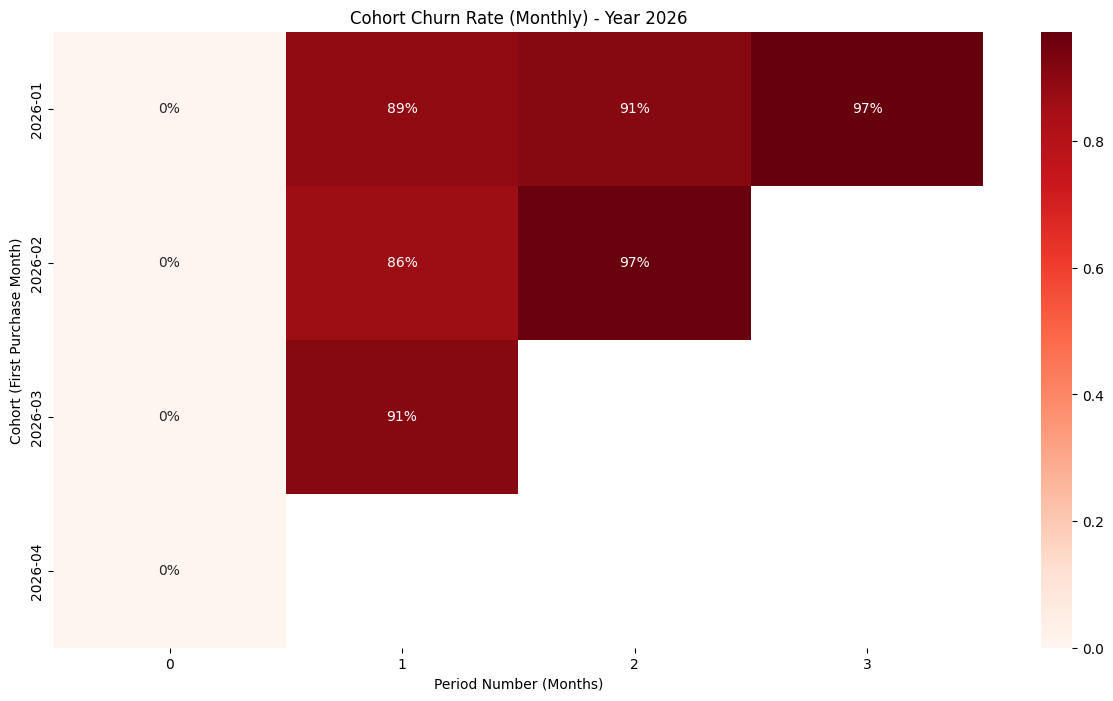

In [22]:
for year in all_years:
    print(f"\n--- Cohort Churn Analysis for Year: {year} ---")

    df_year = df[df['created_at'].dt.year == year].copy()

    if df_year.empty:
        print(f"No data for year {year}, skipping.")
        continue

    df_year['order_month'] = df_year['created_at'].dt.to_period('M')
    df_year['cohort'] = df_year.groupby('user_id')['order_month'].transform('min')

    cohort_data_yearly = df_year.groupby(['cohort', 'order_month'])['user_id'].nunique().reset_index()

    cohort_data_yearly['period_number'] = (cohort_data_yearly.order_month - cohort_data_yearly.cohort).apply(lambda x: x.n)

    cohort_pivot_yearly = cohort_data_yearly.pivot_table(index='cohort', columns='period_number', values='user_id')

    cohort_sizes_yearly = cohort_pivot_yearly.iloc[:,0]
    retention_matrix_yearly = cohort_pivot_yearly.divide(cohort_sizes_yearly, axis=0)

    # Calculate churn matrix for the yearly-monthly analysis
    churn_matrix_yearly = 1 - retention_matrix_yearly

    plt.figure(figsize=(15, 8))
    sns.heatmap(churn_matrix_yearly, annot=True, fmt='.0%', cmap='Reds')
    plt.title(f'Cohort Churn Rate (Monthly) - Year {year}')
    plt.xlabel('Period Number (Months)')
    plt.ylabel('Cohort (First Purchase Month)')
    plt.show()

##Churn Indication

In [23]:
last_purchase = df.groupby('user_id')['created_at'].max()
inactive_users = last_purchase[last_purchase < (snapshot_date - pd.Timedelta(days=90))]

In [24]:
inactive_users

,created_at
user_id,
2,2023-09-30 05:53:26+00:00
3,2023-08-05 15:32:15+00:00
4,2023-11-27 06:41:35+00:00
6,2023-02-21 16:21:55+00:00
7,2024-11-11 12:37:44+00:00
...,...
99996,2020-08-07 00:12:29+00:00
99997,2022-03-12 01:05:16+00:00
99998,2024-04-10 06:33:46+00:00


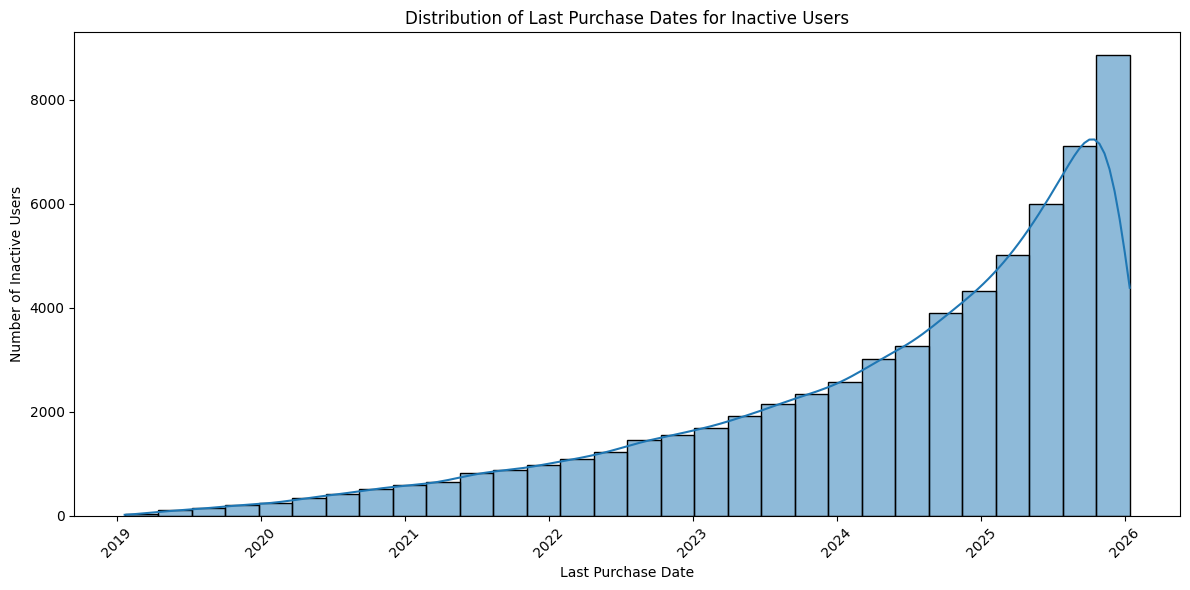

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(inactive_users, kde=True, bins=30)
plt.title('Distribution of Last Purchase Dates for Inactive Users')
plt.xlabel('Last Purchase Date')
plt.ylabel('Number of Inactive Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Calculate the percentage of inactive users by cohort year

Percentage of Inactive Users by Cohort Year:
cohort_year
2019    97.271127
2020    96.945475
2021    95.831944
2022    95.211830
2023    94.144731
2024    92.566165
2025    86.557069
2026     5.963618
Freq: Y-DEC, Name: count, dtype: float64


/tmp/ipykernel_12187/1777175759.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentage_inactive_by_cohort.index.astype(str), y=percentage_inactive_by_cohort.values, palette='viridis')


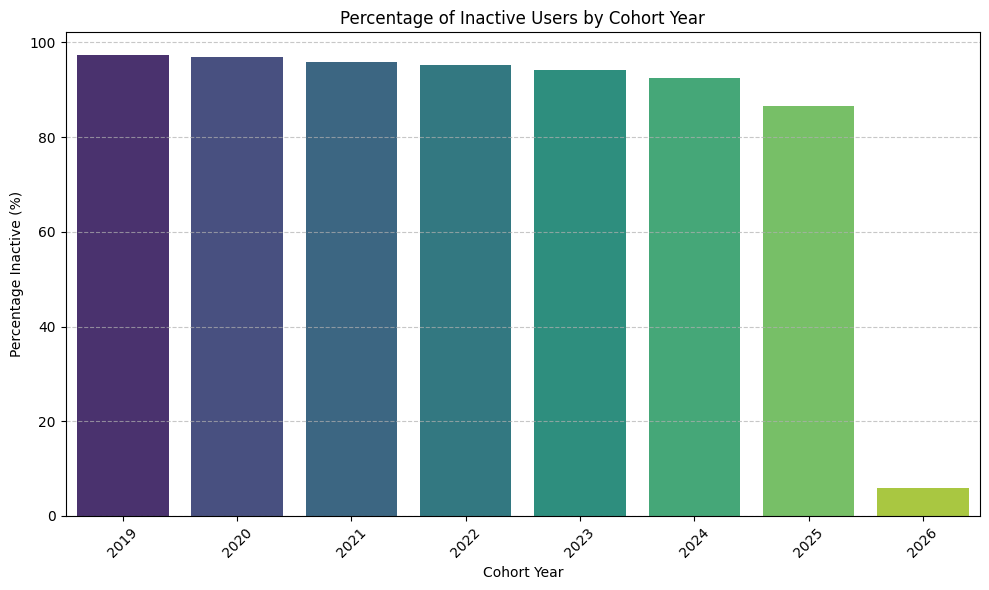

In [26]:
import pandas as pd

# Get the cohort year for each user (first purchase year)
user_cohort = df.groupby('user_id')['cohort'].first().rename('cohort_year')

# Convert inactive_users Series to a DataFrame for easier merging
inactive_users_df = inactive_users.reset_index()
inactive_users_df = inactive_users_df.rename(columns={'created_at': 'last_purchase_date'})

# Merge with user_cohort to get the cohort year of inactive users
inactive_users_with_cohort = inactive_users_df.merge(user_cohort, on='user_id', how='left')

# Count total users per cohort
total_users_per_cohort = user_cohort.value_counts().sort_index()

# Count inactive users per cohort
inactive_users_per_cohort = inactive_users_with_cohort['cohort_year'].value_counts().sort_index()

# Calculate percentage of inactive users per cohort
percentage_inactive_by_cohort = (inactive_users_per_cohort / total_users_per_cohort * 100).fillna(0)

print("Percentage of Inactive Users by Cohort Year:")
print(percentage_inactive_by_cohort)

# Visualize the percentage
plt.figure(figsize=(10, 6))
sns.barplot(x=percentage_inactive_by_cohort.index.astype(str), y=percentage_inactive_by_cohort.values, palette='viridis')
plt.title('Percentage of Inactive Users by Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Percentage Inactive (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

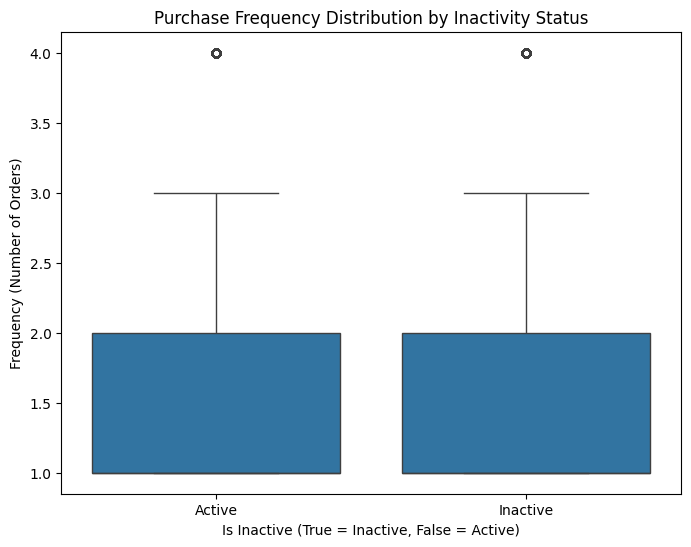

In [27]:
rfm['is_inactive'] = rfm.index.isin(inactive_users.index)

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_inactive', y='frequency', data=rfm)
plt.title('Purchase Frequency Distribution by Inactivity Status')
plt.xlabel('Is Inactive (True = Inactive, False = Active)')
plt.ylabel('Frequency (Number of Orders)')
plt.xticks([0, 1], ['Active', 'Inactive'])
plt.show()

In [28]:
mean_frequency_by_status = rfm.groupby('is_inactive')['frequency'].mean()
print("Average Purchase Frequency by Inactivity Status:")
print(mean_frequency_by_status)

Average Purchase Frequency by Inactivity Status:
is_inactive
False    1.815335
True     1.498811
Name: frequency, dtype: float64


#ML Project Extension [Predicting Customer Churn Using Machine Learning]
Membangun model machine learning untuk memprediksi kemungkinan customer akan berhenti bertransaksi (churn), sehingga bisnis dapat melakukan tindakan preventif.

##Definisi Churn

In [29]:
df

,order_id,user_id,product_id,sale_price,created_at,country,name,month,order_year,cohort
0,11189,9028,29033,3.95,2024-07-07 19:33:40+00:00,Poland,HDE Pattern Suspenders,2024-07,2024,2023
1,95861,76643,14225,5.99,2024-07-20 07:35:24+00:00,Poland,New Classy Womens Skinny Leather Belt with Shi...,2024-07,2024,2024
2,111531,89097,25322,5.99,2023-02-14 10:43:06+00:00,Poland,RHINO SOCKS SS series Bikapelli crimson/navy a...,2023-02,2023,2023
3,101540,81193,9498,6.99,2026-03-17 18:09:17+00:00,Poland,Soxnet Women's Neon Socks - Solid Colors Low C...,2026-03,2026,2026
4,59561,47836,14116,6.99,2026-02-03 22:04:52+00:00,Poland,Premium Flower Print Scarf (2 Colors Available...,2026-02,2026,2026
...,...,...,...,...,...,...,...,...,...,...
181582,117774,94092,8429,903.00,2023-10-23 20:17:40+00:00,United States,The North Face Women's S-XL Oso Jacket,2023-10,2023,2022
181583,70929,56826,24110,990.00,2025-10-22 04:00:24+00:00,United States,Woolrich Arctic Parka DF,2025-10,2025,2025
181584,100496,80357,24110,990.00,2026-01-25 12:54:32+00:00,United States,Woolrich Arctic Parka DF,2026-01,2026,2021
181585,51182,41070,24447,999.00,2023-06-06 02:25:00+00:00,United States,Darla,2023-06,2023,2023


In [30]:
df['last_purchase'] = df.groupby('user_id')['created_at'].transform('max')

snapshot_date = df['created_at'].max()

df['churn'] = (snapshot_date - df['last_purchase']).dt.days > 90

/tmp/ipykernel_12187/3503995083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['last_purchase'] = df.groupby('user_id')['created_at'].transform('max')
/tmp/ipykernel_12187/3503995083.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['churn'] = (snapshot_date - df['last_purchase']).dt.days > 90


##Feature Engineering

In [31]:
rfm = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'sale_price': 'sum'
})

rfm.columns = ['recency', 'frequency', 'monetary']

In [ ]:
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

##Prepare Data

In [32]:
import datetime as dt
from sklearn.model_selection import train_test_split

# Ensure snapshot_date is available
snapshot_date = df['created_at'].max()

# 1. Recalculate RFM from a clean state to prevent merge errors
rfm_clean = df.groupby('user_id').agg({
    'created_at': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'sale_price': 'sum'
})
rfm_clean.columns = ['recency', 'frequency', 'monetary']

# 2. Calculate avg_order_value
rfm_clean['avg_order_value'] = rfm_clean['monetary'] / rfm_clean['frequency']

# Get the churn status for each user from the original df
# This 'churn' column is derived from `df['churn']` created earlier.
user_churn_status = df.groupby('user_id')['churn'].first()

# 3. Add the churn status to the rfm DataFrame
# Since 'rfm_clean' does not have a 'churn' column, this merge will add a single 'churn' column without suffixes.
rfm = rfm_clean.merge(user_churn_status, on='user_id', how='left')

# 'recency' is explicitly removed from features to prevent data leakage in churn prediction.
# The 'churn' column is the target variable and MUST be removed from the feature set 'X'.
X = rfm.drop(columns=['recency', 'churn'], errors='raise') # Drop recency and the 'churn' column from features
y = rfm['churn'] # 'churn' is the correct target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Retrain the model with the updated X_train and y_train
model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model Evaluation (after addressing data leakage and removing 'recency'):")
print(classification_report(y_test, y_pred))

# Display feature importances again
importance = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature Importances (after addressing data leakage):")
print(importance.sort_values(ascending=False))

Model Evaluation (after addressing data leakage and removing 'recency'):
              precision    recall  f1-score   support

       False       0.26      0.15      0.19      3319
        True       0.80      0.89      0.84     12694

    accuracy                           0.73     16013
   macro avg       0.53      0.52      0.51     16013
weighted avg       0.69      0.73      0.71     16013


Feature Importances (after addressing data leakage):
monetary           0.487762
avg_order_value    0.484065
frequency          0.028173
dtype: float64


##Model Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

##Evaluation

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.25      0.15      0.19      3319
        True       0.80      0.89      0.84     12694

    accuracy                           0.73     16013
   macro avg       0.53      0.52      0.51     16013
weighted avg       0.69      0.73      0.71     16013



In [36]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
monetary,0.487698
avg_order_value,0.485100
frequency,0.027202


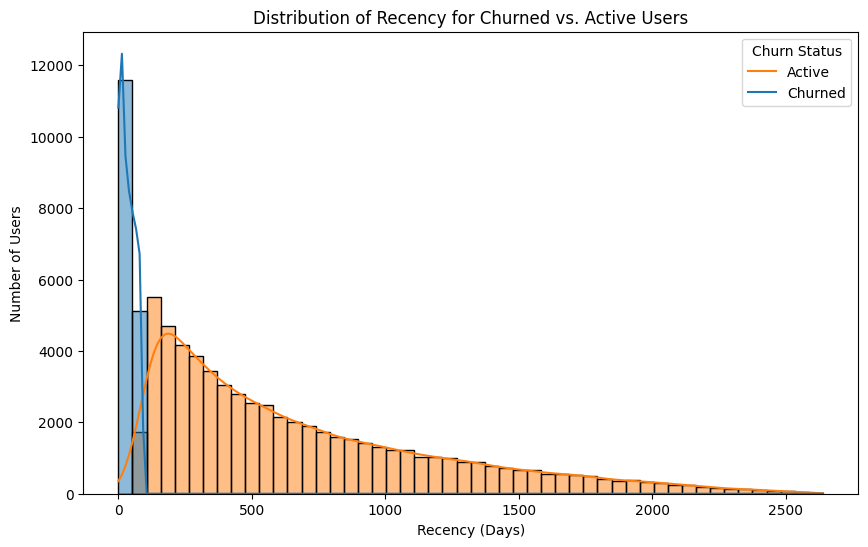

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=rfm, x='recency', hue='churn', kde=True, bins=50)
plt.title('Distribution of Recency for Churned vs. Active Users')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Users')
plt.legend(title='Churn Status', labels=['Active', 'Churned'])
plt.show()